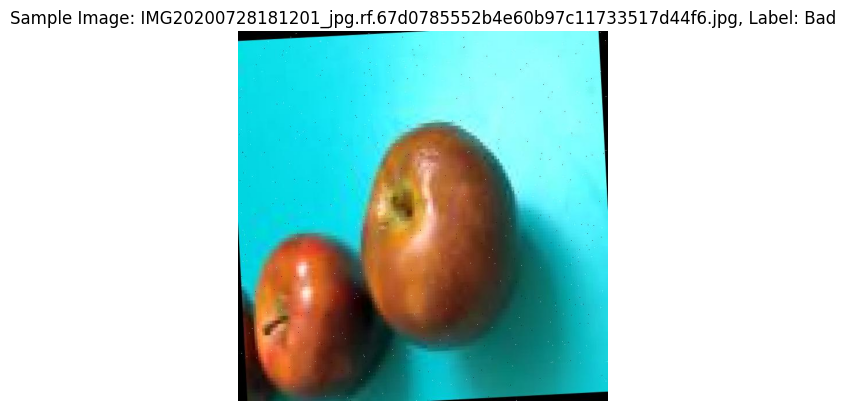

Sample Label: Bad


In [17]:
import os
import matplotlib.pyplot as plt
import cv2
import random

# train, valid 디렉토리
train_dir = "data/cnn_train"
valid_dir = "data/cnn_valid"

def get_sample_image(dir_path):
    categories = [d for d in os.listdir(dir_path) if os.path.isdir(os.path.join(dir_path, d))]
    category = random.choice(categories)
    category_path = os.path.join(dir_path, category)
    sample_img = random.choice(os.listdir(category_path))
    img_path = os.path.join(category_path, sample_img)
    return img_path, category

# train 샘플
img_path, label = get_sample_image(train_dir)

# 이미지 시각화
img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Sample Image: {os.path.basename(img_path)}, Label: {label}")
plt.axis('off')
plt.show()

print(f"Sample Label: {label}")


In [18]:
# OpenCV 기반 불량 감지

import time

def detect_defect(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)
    
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h
        if area > 500 or aspect_ratio < 0.8 or aspect_ratio > 1.2:
            return "bad"
    return "good"

def batch_detect(images_root_dir):
    results = {}
    start_time = time.time()
    for category in ["good", "bad"]:
        category_path = os.path.join(images_root_dir, category)
        for img_file in os.listdir(category_path):
            img_path = os.path.join(category_path, img_file)
            pred = detect_defect(img_path)
            results[img_file] = pred
    elapsed = time.time() - start_time
    print(f"OpenCV detection finished in {elapsed:.2f} sec")
    return results

# OpenCV 결과 확인
opencv_results_train = batch_detect(train_dir)
print(list(opencv_results_train.items())[:5])


OpenCV detection finished in 0.88 sec
[('20190809_122412_jpg.rf.14a7dc799d0eb13cb694d1fe08677651.jpg', 'bad'), ('20190809_122412_jpg.rf.388bafb402b905eadb240e515b931f2e.jpg', 'bad'), ('20190809_122412_jpg.rf.6ae3441a3996044cc318aa57961deeeb.jpg', 'bad'), ('20190809_122412_jpg.rf.8965db4dae924f7b568443d4fb781373.jpg', 'bad'), ('20190809_122412_jpg.rf.a4d35a175509e5ae2e92ace098082784.jpg', 'bad')]


In [19]:
# CNN 기반 분류(전이학습, flow_from_dataframe 대체)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

num_classes = len(train_gen.class_indices)
print(f"Number of classes: {num_classes}")

Found 240 images belonging to 2 classes.
Found 19 images belonging to 2 classes.
Number of classes: 2


In [20]:
# CNN 모델 구성 & 학습

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
output = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# base model freeze
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=10)
model.save("fruit_cnn_model.keras")


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.7750 - loss: 0.5536 - val_accuracy: 0.5789 - val_loss: 1.1142
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.8375 - loss: 0.3561 - val_accuracy: 0.5789 - val_loss: 1.0503
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.9125 - loss: 0.2578 - val_accuracy: 0.5263 - val_loss: 0.9228
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.9292 - loss: 0.2169 - val_accuracy: 0.5263 - val_loss: 0.9204
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.9500 - loss: 0.1594 - val_accuracy: 0.5789 - val_loss: 0.9100
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.9625 - loss: 0.1295 - val_accuracy: 0.5789 - val_loss: 1.1986
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.9750 - loss: 0.1137 - val_accuracy: 0.5789 - val_loss: 1.0559
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.9792 - loss: 0.1107 - val_accuracy: 0.

In [21]:
# 평가

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

val_labels = val_gen.classes
val_pred_prob = model.predict(val_gen)
val_pred = np.argmax(val_pred_prob, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(val_labels, val_pred))

print("\nClassification Report:")
print(classification_report(val_labels, val_pred, target_names=list(train_gen.class_indices.keys())))


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 967ms/step
Confusion Matrix:
[[ 0  8]
 [ 0 11]]

Classification Report:
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         8
        Good       0.58      1.00      0.73        11

    accuracy                           0.58        19
   macro avg       0.29      0.50      0.37        19
weighted avg       0.34      0.58      0.42        19



C:\Users\njy60\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njy60\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njy60\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [1]:
# 개선

import os, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



train_dir = "data/cnn_train"
valid_dir = "data/cnn_valid"

# OpenCV Rule-based 감지
# HSV 색 구분 기반 + good/bad 색 영역 비율 기반 기준 추가
def detect_defect(image_path):
    img = cv2.imread(image_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Good 색 범위 (red + green)
    lower_red1 = np.array([0, 80, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 80, 50])
    upper_red2 = np.array([180, 255, 255])

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])

    mask_red = cv2.inRange(hsv, lower_red1, upper_red1) + \
               cv2.inRange(hsv, lower_red2, upper_red2)

    mask_green = cv2.inRange(hsv, lower_green, upper_green)

    good_mask = mask_red + mask_green

    # Bad 색 범위 (brown, yellow, dark)
    lower_brown = np.array([10, 30, 20])
    upper_brown = np.array([25, 255, 200])

    lower_dark = np.array([0, 0, 0])
    upper_dark = np.array([180, 255, 50])

    mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)
    mask_dark = cv2.inRange(hsv, lower_dark, upper_dark)

    bad_mask = mask_brown + mask_dark

    # 픽셀 비율 계산
    total_pixels = img.shape[0] * img.shape[1]
    
    bad_ratio = np.sum(bad_mask > 0) / total_pixels
    good_ratio = np.sum(good_mask > 0) / total_pixels

    # 판단 기준
    if bad_ratio > 0.3:        # 전체의 5% 이상이 bad color → 불량
        return "bad"

    return "good"

def batch_detect(images_root_dir):
    results, start_time = [], time.time()
    for label_folder in ["good", "bad"]:
        folder_path = os.path.join(images_root_dir, label_folder)
        for img_file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_file)
            pred = detect_defect(img_path)
            results.append((img_file, pred, label_folder))
    print(f"OpenCV detection finished in {time.time()-start_time:.2f} sec")
    return results

# CNN 기반 감지
# MobileNetV2 사용 전처리 강화
# class_weight 적용
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=16, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    valid_dir, target_size=(224,224), batch_size=16, class_mode='categorical', shuffle=False
)

num_classes = len(train_gen.class_indices)

# 2. MobileNetV2 Base Model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
x = GlobalAveragePooling2D()(base_model.output)
output = Dense(num_classes, activation='softmax')(x)
cnn_model = Model(base_model.input, output)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))

print("Train head only")
cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights, 
    verbose=0
)

# Unfreeze top 30%
total_layers = len(base_model.layers)
trainable_from = int(total_layers * 0.7)

for i, layer in enumerate(base_model.layers):
    if i >= trainable_from:
        layer.trainable = True

# Fine-tuning → LR must be very small
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning")
cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights, 
    verbose=0
)

cnn_model.save("fruit_cnn_model.keras")


def evaluate_model(model, gen):
    labels = gen.classes
    preds = model.predict(gen)
    pred_labels = np.argmax(preds, axis=1)
    
    print("Confusion Matrix:")
    print(confusion_matrix(labels, pred_labels))
    print("\nClassification Report:")
    print(classification_report(
        labels,
        pred_labels,
        target_names=list(gen.class_indices.keys())
    ))

# OpenCV 평가
print("=== OpenCV Rule-based Detection ===")
opencv_results = batch_detect(valid_dir)
true_labels = [label for _,_,label in opencv_results]
pred_labels = [pred for _,pred,_ in opencv_results]

print("Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels))
print()

# CNN 평가
print("=== CNN based Detection ===")
evaluate_model(cnn_model, val_gen)

Found 240 images belonging to 2 classes.
Found 19 images belonging to 2 classes.
Train head only
Fine-tuning
=== OpenCV Rule-based Detection ===
OpenCV detection finished in 0.30 sec
Confusion Matrix:
[[3 5]
 [2 9]]

Classification Report:
              precision    recall  f1-score   support

         bad       0.60      0.38      0.46         8
        good       0.64      0.82      0.72        11

    accuracy                           0.63        19
   macro avg       0.62      0.60      0.59        19
weighted avg       0.62      0.63      0.61        19


=== CNN based Detection ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step
Confusion Matrix:
[[ 4  4]
 [ 1 10]]

Classification Report:
              precision    recall  f1-score   support

         Bad       0.80      0.50      0.62         8
        Good       0.71      0.91      0.80        11

    accuracy                           0.74        19
   macro avg       0.76      0.70      0.71        19
weighted avg       0.75      0.74  